---
title: Lattice Kinetic Monte Carlo Assignment
short_title: Lattice KMC Assignment
authors: gvarnavides
date: 2026-06-02
---

In this assignment, we will investigate how interacting particles organize on a lattice using probabilistic simulations.
The goal is to connect ideas from statistical physics, such as energy, temperature, entropy, and chemical potential, to the microscopic dynamics of a many-particle system.

We consider a simple model of a binary mixture on a square lattice.
Each lattice site may contain either a blue particle, a red particle, or a vacancy (an empty site).
The particles interact with their neighbors, and thermal fluctuations allow the system to evolve over time.

## Lattice Kinetic Monte Carlo

Kinetic Monte Carlo (KMC) is a stochastic simulation method used to model the time evolution of systems with thermally activated dynamics.
Rather than solving equations of motion directly, KMC evolves the system through a sequence of probabilistic microscopic changes, such as particles moving or changing state.

In our lattice model, each site $i$ is assigned a variable $s_i \in {−1,0,1}$, where $s_i = -1$ corresponds to a blue particle, $s_i = 1$ corresponds to a red particle, and $s_i = 0$ corresponds to a vacancy.

The system evolves through local updates, such as exchanging a particle with a neighboring vacancy.
Whether a proposed move is accepted depends on how it changes the total energy of the system.

At low temperature, the system tends to evolve toward ordered low-energy configurations.
At higher temperature, thermal fluctuations become stronger and disorder is favored.
KMC therefore allows us to study how microscopic interactions compete with thermal entropy.

### Pairwise Hamiltonian

To describe the energetics of the lattice, we define the total energy function of the system
$$
\mathcal{H} = \sum_{\langle i,j\rangle} J_1 s_i s_j + \sum_{\langle\langle i,j\rangle\rangle} J_2 s_i s_j - \sum_i (\mu_B \delta_{s_i,-1} + \mu_R \delta_{s_i,1}).
$$  
This expression contains several terms:
- The first sum runs over all nearest-neighbor pairs $\langle i,j\rangle$.
- The second sum runs over next-nearest-neighbor pairs $\langle\langle i,j\rangle\rangle$.
- $J_1$ and $J_2$ determine the interaction strength between neighboring sites.
- The quantities $\mu_B$ and $\mu_R$ are chemical potentials that control how favorable it is to add blue or red particles to the system.
- $\delta_{a,b}$ is the Kronecker delta, equal to 1 when $a=b$ and 0 otherwise.

The products $s_i s_j$ determine whether neighboring sites contribute positively or negatively to the energy.
Depending on the signs of $J_1$ and $J_2$, the system may favor clustering, checkerboard ordering, phase separation, or more complex structures.

In the first part of the assignment, we will work in the canonical ensemble, where the total number of particles is fixed.
Later, we will introduce grand-canonical simulations, where the chemical potentials $\mu_B$ and $\mu_R$ allow particles to enter or leave the system.

### Metropolis Algorithm

The lattice is evolved using the Metropolis-Hastings algorithm.
For each proposed update, we compute the corresponding energy change: $\Delta E = E_{\mathrm{new}} - E_{\mathrm{old}}$.

The move is then accepted with probability:  
$$
\mathcal{P}_\mathrm{accept} =
\begin{cases}
1, & \Delta E \le 0,\\[2mm]
\exp(-\Delta E / k_B T), & \Delta E > 0.
\end{cases}
$$

This means:
- Moves that lower the energy are always accepted.
- Moves that increase the energy may still occur because of thermal fluctuations.
- Higher temperatures make energetically unfavorable moves more likely.

This update rule ensures that the simulation samples configurations according to the Boltzmann distribution:
$$
\mathcal{P}(\mathcal{H})\propto \exp(-\mathcal{H}/k_B T).
$$

Over many Monte Carlo steps, the system evolves toward thermal equilibrium while still exhibiting fluctuations and local dynamics.

In [1]:
# Imports
from lattice_kmc import initialize_lattice, run_simulation, plot_lattice_disks, interactive_kmc_canvas, compute_fractions, total_energy
import matplotlib.pyplot as plt
import numpy as np

MODE_CANONICAL = 0
MODE_GRAND_CANONICAL = 1
MODE_SURFACE_GRAND_CANONICAL = 2

## Example Simulation

We begin with a square lattice initialized with randomly distributed blue particles, red particles, and vacancies according to the probabilities $(0.45,0.45,0.1)$

In [ ]:
#| label: square_lattice_example
# Initialize square lattice
nx, ny = (56,56)
lattice,vacancy_coords = initialize_lattice((nx,ny),seed=2026)

# 1,000,000 steps at constant composition and temperature
ordered_lattice, ordered_vac = run_simulation(
    lattice,
    vacancy_coords,
    n_steps = 1_000_000,
    T=5.0,
    J1=-10.0,
    J2=10.0,
    mode= MODE_CANONICAL
)

fig, axs = plt.subplots(1,2,figsize=(10.5,6))
plot_lattice_disks(lattice,ax=axs[0])
plot_lattice_disks(ordered_lattice,ax=axs[1])
axs[0].set_title("Initial lattice")
axs[1].set_title("Ordered lattice after 1,000,000 MC steps")
fig.tight_layout()

### Part 2a: Canonical Ensemble Ordering Phases

In this exercise, we will investigate how different interaction parameters produce different types of lattice ordering.
Run lattice KMC simulations at fixed composition and a normalized temperature $T=5.0$ to obtain equilibrated lattices for the following interaction parameters:
- $ J_1 = -10,\; J_2 = 0 $
- $ J_1 = -10,\; J_2 = 10 $
- $ J_1 = 10,\; J_2 = -10 $

For each simulation:
1. Plot the final lattice configuration.

In [ ]:
#| label: square_lattice_example
# Initialize square lattice
nx, ny = (56,56)
lattice,vacancy_coords = initialize_lattice((nx,ny),seed=2026)

# 1,000,000 steps at constant composition and temperature
ordered_lattice1, ordered_vac1 = run_simulation(
    lattice,
    vacancy_coords,
    n_steps = 1_000_000,
    T=5.0,
    J1=-10.0,
    J2= 0.0,
    mode= MODE_CANONICAL
)

# 1,000,000 steps at constant composition and temperature
ordered_lattice2, ordered_vac2 = run_simulation(
    lattice,
    vacancy_coords,
    n_steps = 1_000_000,
    T=5.0,
    J1=-10.0,
    J2= 10.0,
    mode= MODE_CANONICAL
)

# 1,000,000 steps at constant composition and temperature
ordered_lattice3, ordered_vac3 = run_simulation(
    lattice,
    vacancy_coords,
    n_steps = 1_000_000,
    T=5.0,
    J1=-10.0,
    J2= -10.0,
    mode= MODE_CANONICAL
)


fig, axs = plt.subplots(1,3,figsize=(14,15))
plot_lattice_disks(ordered_lattice1,ax=axs[0])
axs[0].set_title(r"$J_1=-10$, $J_2=0$")

plot_lattice_disks(ordered_lattice2,ax=axs[1])
axs[1].set_title(r"$J_1=-10$, $J_2=10$")

plot_lattice_disks(ordered_lattice3,ax=axs[2])
axs[2].set_title(r"$J_1=10$, $J_2=-10$")

fig.tight_layout(pad=2)
plt.savefig("img/P2/2.1a.png", dpi=300, bbox_inches='tight')
plt.show()

2. Compute and plot the structure factor
   
   $$
   S(\mathbf{q})
   =
   \left|
   \mathcal{F}_{\mathbf{r}\to\mathbf{q}}
   \left[s(\mathbf{r})\right]
   \right|^2,
   $$

   where $\mathcal{F}$ denotes the discrete Fourier transform.


In [ ]:
s_r1 = ordered_lattice1[3:-3,3:-3]
s_r2 = ordered_lattice2[3:-3,3:-3]
s_r3 = ordered_lattice3[3:-3,3:-3]

def FFT(s_r):
    #Discrete fourier transforms
    s_r_fft = np.fft.fft2(s_r)
    s_r_fft_shifted = np.fft.fftshift(s_r_fft)
    S_q = np.abs(s_r_fft_shifted)**2

    return S_q

#Plotting everything
fig, (ax1, ax2, ax3) = plt.subplots(figsize=(15, 5), ncols=3)
pos = ax1.imshow(FFT(s_r1), cmap='viridis', interpolation='none')
fig.colorbar(pos, ax=ax1,shrink=0.7)
plt.title(r"$J_1=-10$, $J_2=0$")

pos = ax2.imshow(FFT(s_r2), cmap='viridis', interpolation='none')
fig.colorbar(pos, ax=ax2,shrink=0.7)
plt.title(r"$J_1=-10$, $J_2=10$")

pos = ax3.imshow(FFT(s_r3), cmap='viridis', interpolation='none')
fig.colorbar(pos, ax=ax3,shrink=0.7)
plt.title(r"$J_1=10$, $J_2=-10$")

fig.tight_layout()
plt.savefig("img/P2/2.2a.png", dpi=300, bbox_inches='tight')
plt.show()

Interpretaties:
- De eerste plot heeft punten geclusterd rondom het midden. Dit is verwacht omdat de plaats domein grote groeperingen weergeeft (wat analoog is aan lage frequentie). Hetzelfde geldt voor de 3de plot.
- De tweede plot heeft specifieke 'frequnetie waarden'. In plaats domein is dit terug te zien omdat er een duidelijk patroon te zien is; veel om en om.

3. Compute and plot the horizontal and vertical correlation functions

   $$
   C_h(r)
   =
   \left\langle
   s(i,j)\, s(i+r,j)
   \right\rangle,
   $$

   where the average is taken over all lattice positions.


In [ ]:
## Navragen: Ik neem aan dat ze doorschuivingen willen? s(49,49)*s(50,49)=s(49,49)*s(0,49). Ik gebruik roll methode namelijk dan.
N = s_r1.shape[0]
r = np.arange(N)


def rollfunc(s_r):
    C_h_hor = np.zeros(N)
    C_h_ver = np.zeros(N)

    #roll methode toepassen, bespaard geheugen.
    for i in r:
        s_r_shifted_ver = np.roll(s_r,shift=i, axis=0)
        C_h_ver[i] = np.mean(s_r_shifted_ver*s_r) #verwachtingswaarde berekenen
        
        s_r_shifted_hor = np.roll(s_r,shift=i, axis=1)
        C_h_hor[i] = np.mean(s_r_shifted_hor*s_r) #verwachtingswaarde berekenen
        

    #Sanity check
    ##print(s_r1)
    ##print()
    ##print(np.roll(s_r1,shift=1, axis=1)) #horizontal rolling
    
    return C_h_hor, C_h_ver


C_h_hor1, C_h_ver1 = rollfunc(s_r1)
C_h_hor2, C_h_ver2 = rollfunc(s_r2)
C_h_hor3, C_h_ver3 = rollfunc(s_r3)


#plotting
fig = plt.figure(figsize=((12,4)))
plt.subplot(1, 3, 1)
plt.plot(r,C_h_hor1, "-", label=rf'Horizontal')
plt.plot(r,C_h_ver1, "-", label=rf'Vertical')
plt.ylabel(r"$r$ (-)", fontsize=14)
plt.xlabel(r"$C_h$ (-)", fontsize=14)
plt.title(r"$J_1=-10$, $J_2=0$")
plt.xticks(fontsize=12) 
plt.yticks(fontsize=12) 
plt.legend(fontsize=12) 
plt.grid()
plt.tight_layout()

plt.subplot(1, 3, 2)
plt.plot(r,C_h_hor2, "-", label=rf'Horizontal')
plt.plot(r,C_h_ver2, "-", label=rf'Vertical')
plt.ylabel(r"$r$ (-)", fontsize=14)
plt.xlabel(r"$C_h$ (-)", fontsize=14)
plt.xticks(fontsize=12) 
plt.yticks(fontsize=12) 
plt.legend(fontsize=12) 
plt.grid()
plt.tight_layout()
plt.title(r"$J_1=-10$, $J_2=10$")

plt.subplot(1, 3, 3)
plt.plot(r,C_h_hor3, "-", label=rf'Horizontal')
plt.plot(r,C_h_ver3, "-", label=rf'Vertical')
plt.ylabel(r"$r$ (-)", fontsize=14)
plt.xlabel(r"$C_h$ (-)", fontsize=14)
plt.xticks(fontsize=12) 
plt.yticks(fontsize=12) 
plt.legend(fontsize=12) 
plt.grid()
plt.tight_layout()
plt.title(r"$J_1=10$, $J_2=-10$")
plt.savefig("img/P2/2.3a.png", dpi=300, bbox_inches='tight')

plt.show()

4. Compute the following scalar order parameters:
   - Checkerboard ordering:

     $$
     m_{\mathrm{AF}}
     =
     \frac{1}{N}
     \sum_{i,j}
     (-1)^{i+j} s(i,j)
     $$

   - Vertical stripe ordering:

     $$
     m_{\mathrm{stripe},v}
     =
     \frac{1}{N}
     \sum_{i,j}
     (-1)^i s(i,j)
     $$

   - Horizontal stripe ordering:

     $$
     m_{\mathrm{stripe},h}
     =
     \frac{1}{N}
     \sum_{i,j}
     (-1)^j s(i,j)
     $$

Here, $N$ is the total number of lattice sites.

Discuss how the real-space ordering patterns relate to the peaks observed in the structure factor and the values of the order parameters.

In [ ]:
#Function for the scalar order parameters
def ordering_func(s_r):

    #CHECKERBOARD
    sum=0
    for i in np.arange(N):
        for j in np.arange(N):
            sum += (-1)**(i+j)*s_r[(i,j)]
            
    m_AF = sum/N**2

    #VERTICAL STRIPES
    sum=0
    for i in np.arange(N):
        for j in np.arange(N):
            sum += (-1)**(i)*s_r[(i,j)]
            
    m_stripe_v = sum/N**2

    #HORIZONTAL STRIPES
    sum=0
    for i in np.arange(N):
        for j in np.arange(N):
            sum += (-1)**(j)*s_r[(i,j)]
            
    m_stripe_h = sum/N**2

    return m_AF, m_stripe_v, m_stripe_h


#Getting results
m_AF1, m_stripe_v1, m_stripe_h1 = ordering_func(s_r1)
m_AF2, m_stripe_v2, m_stripe_h2 = ordering_func(s_r2)
m_AF3, m_stripe_v3, m_stripe_h3 = ordering_func(s_r3)


#printing results
print(r'J_1=-10, J_2=0: Checkerboard: %f, vertical strips: %f, horizontal stripes: %f'%(m_AF1, m_stripe_v1, m_stripe_h1))
print()
print(r'J_1=-10, J_2=10: Checkerboard: %f, vertical strips: %f, horizontal stripes: %f'%(m_AF2, m_stripe_v2, m_stripe_h2))
print()
print(r'J_1=10, J_2=-10: Checkerboard: %f, vertical strips: %f, horizontal stripes: %f'%(m_AF3, m_stripe_v3, m_stripe_h3))



#Sanity check
#def checkerboard(shape):
#    grid = np.indices(shape).sum(axis=0) % 2
#    return 1 - 2*grid

#m_AF1, m_stripe_v1, m_stripe_h1 = ordering_func(checkerboard((N,N)))

#print(m_AF1)

### Part 2b: Grand-Canonical Ensemble

In the grand-canonical ensemble, the total number of particles is no longer fixed.  
Instead, the chemical potentials $\mu_B$ and $\mu_R$ control how favorable it is for blue and red particles to occupy lattice sites.
In this exercise, we will investigate how the lattice composition changes as the chemical potential is varied.

Run lattice KMC simulations using: $ J_1 = -2.5,\; J_2 = 0,\; T = 2.5 $ in `MODE_GRAND_CANONICAL`, while varying $\mu_B = -\mu_R \in[-1.5,\,1.5].$

For each value of $\mu_B$:
1. Run the simulation until the system reaches equilibrium.
2. Compute the fraction of blue sites

   $$
   f_B
   =
   \left\langle
   \delta_{s,-1}
   \right\rangle,
   $$
   where $\delta_{s,-1}=1$ for blue sites and $0$ otherwise.

   You may use the `compute_fractions` function for this calculation.
3. Repeat the simulation multiple times and average the results to reduce statistical noise.
4. Plot the average blue-site fraction $f_B$ as a function of $\mu_B$.

In [ ]:
mub=np.linspace(-1.5,1.5,100) #array of mub values to simulate
mur=-mub
nx, ny = (56,56)#defining lattice size
N=20 #number of simulations to run for each value of mub

f_b= np.zeros((N,len(mub))) #array to store fraction of B atoms

lattice,vacancy_coords = initialize_lattice((nx,ny),seed=2026) #initializing the lattice

for i in range(N):
    
    for j in range(len(mub)):
        ordered_lattice, ordered_vac = run_simulation(
            lattice,
            vacancy_coords,
            n_steps = 1_000_000, #we are assuming that 1 million steps is enough to reach equilibrium for all values of mub (this was confirmed by georgios)/10 milion is too many timewise, but better
            T=2.5,
            J1=-2.5,#T,J1 and J2 are given in the assignment.
            J2=0,
            muB=mub[j],#our array of mub values. 
            muR=mur[j],#our array of mua values
            mode= MODE_GRAND_CANONICAL#setting the mode to grand canonical for this part of the assignment
        )
        frac_r,frac_b,frac_v = compute_fractions(ordered_lattice)
        f_b[i,j]=frac_b #adding the value of f_b for this value of mub to the array
f_bavg=np.mean(f_b,axis=0) #average fraction of B atoms for each value of mub over N simulations
 

plt.plot(mub,f_bavg)
plt.ylabel(r"$.$ (-)", fontsize=14)
plt.xlabel(r"$.$ (-)", fontsize=14)
plt.xticks(fontsize=12) 
plt.yticks(fontsize=12) 
plt.grid()
plt.tight_layout()
plt.savefig("img/P2/2.1b.png", dpi=300, bbox_inches='tight')
plt.show()

5. Numerically estimate and plot the susceptibility-like response

   $$
   \frac{\partial f_B}{\partial \mu_B}
   $$
   as a function of $\mu_B$.

In [ ]:
fig = plt.figure(figsize=((12,4)))
susc_b = np.diff(f_bavg)/np.diff(mub) #numerical derivative of f_b with respect to mub
plt.subplot(1,4,1)
plt.plot(mub[:-1],susc_b, label="derivative of raw data")
plt.ylabel(r"$.$ (-)", fontsize=14)
plt.xlabel(r"$.$ (-)", fontsize=14)
plt.xticks(fontsize=12) 
plt.yticks(fontsize=12) 
plt.legend(fontsize=12, loc='upper right') 
plt.tight_layout()
plt.grid()


# clearly not very smooth. try cubicspline 

from scipy.interpolate import CubicSpline

cs = CubicSpline(mub, f_bavg,axis=1) #creating the cubic spline interpolation
mub_fine = np.linspace(mub[0], mub[-1], 100000)
f_bavg_smooth = cs(mub_fine)
susc_b_smooth = np.gradient(f_bavg_smooth, mub_fine)#taking the derivative.
plt.subplot(1,4,2)
plt.plot(mub_fine, susc_b_smooth, label="cubic spline")#plotting
plt.ylabel(r"$.$ (-)", fontsize=14)
plt.xlabel(r"$.$ (-)", fontsize=14)
plt.xticks(fontsize=12) 
plt.yticks(fontsize=12) 
plt.legend(fontsize=12, loc='upper right') 
plt.tight_layout()
plt.grid()


#also not working great. stackexchange mentions a savgal filter. 

from scipy.signal import savgol_filter
f_bavg_smooth_savgol = savgol_filter(f_bavg, 11, 3) # window size 11, polynomial order 3- seems to give smoothest- i just tried different values to find what works best. 
susc_b_smooth_savgol = np.gradient(f_bavg_smooth_savgol, mub)
plt.subplot(1,4,3)  
plt.plot(mub, susc_b_smooth_savgol,label="savgol filter")
plt.ylabel(r"$.$ (-)", fontsize=14)
plt.xlabel(r"$.$ (-)", fontsize=14)
plt.xticks(fontsize=12) 
plt.yticks(fontsize=12) 
plt.legend(fontsize=12, loc='upper right') 
plt.tight_layout()
plt.grid()



#lets lastly try a simple function fit for f_bavg. it looks somewhat like a tanh. 

from scipy.optimize import curve_fit

def func_fit(x, a, b, c,d):
    return  a*np.tanh(b*x + c) + d

popt, pcov = curve_fit(func_fit, mub, f_bavg)
f_bavg_fit = func_fit(mub, *popt)
susc_b_fit = np.gradient(f_bavg_fit, mub)


plt.subplot(1,4,4)

plt.plot(mub, susc_b_fit, label="derivative of function fit")

plt.ylabel(r"$.$ (-)", fontsize=14)
plt.xlabel(r"$.$ (-)", fontsize=14)
plt.xticks(fontsize=12) 
plt.yticks(fontsize=12) 
plt.legend(fontsize=12, loc='upper right') 
plt.tight_layout()
plt.grid()

plt.savefig("img/P2/2.2b.png", dpi=300, bbox_inches='tight')
plt.show()

# clearly the function fit gives the smoothest result. 

#### some further exploration using the tanh functionfit approach

In [ ]:
#Plot 1
plt.figure()
plt.plot(mub, f_bavg,".", label="raw data")
plt.plot(mub, f_bavg_fit, label="function fit")
plt.xlabel(r"$\mu_b$", fontsize=14)
plt.ylabel(r"$f_b$", fontsize=14)
plt.xticks(fontsize=12) 
plt.yticks(fontsize=12) 
plt.legend(fontsize=12) 
plt.grid()
plt.tight_layout()
plt.savefig("img/P2/2.3b.png", dpi=300, bbox_inches='tight')
plt.show()


#Plot 2
plt.figure()
plt.plot(mub,susc_b_fit, label="derivative of function fit")
plt.xlabel(r"$\mu_b$", fontsize=14)
plt.ylabel(r"$\frac{\partial f_b}{\partial \mu_b}$", fontsize=14)
plt.xticks(fontsize=12) 
plt.yticks(fontsize=12) 
plt.legend(fontsize=12) 
plt.grid()
plt.tight_layout()
plt.savefig("img/P2/2.4b.png", dpi=300, bbox_inches='tight')
plt.show()  



Discuss the following questions:

- Why does increasing $\mu_B$ favor blue particles?
- Why is the curve symmetric about $\mu_B = 0$?
- What does the peak in

  $$
  \frac{\partial f_B}{\partial \mu_B}
  $$
  indicate about the sensitivity of the system to changes in chemical potential?

### Part 2c: Heat Capacity

In this exercise, we will study how thermal fluctuations change with temperature by computing the heat capacity of the lattice system.
Run lattice KMC simulations using: $ J_1 = -2.5,\; J_2 = 0,\; \mu_B = -\mu_R =0.5$ in `MODE_GRAND_CANONICAL`, while varying the temperature $ T \in[1,\,10].$

For each temperature:
1. Run the simulation until the system reaches equilibrium.
2. Use the `total_energy` function to compute the total lattice energy $E$ during the simulation.
3. Estimate the average energy $\langle E \rangle$ and the average squared energy $\langle E^2 \rangle.$
4. Repeat the simulation multiple times and average the results to reduce statistical noise.

In [26]:
#T values
T=np.linspace(1,10,20)

#Repeatings
N = 100

# Initialize square lattice
nx, ny = (56,56)
lattice,vacancy_coords = initialize_lattice((nx,ny),seed=2026)

E_tot = np.zeros((len(T),N))
E_tot_sqr = np.zeros((len(T),N))
E_avg = np.zeros(len(T))
E_avg_sqr = np.zeros(len(T))

for j in np.arange(N):
    for i in range(len(T)):
        ordered_lattice, ordered_vac = run_simulation(
            lattice,
            vacancy_coords,
            n_steps = 1_000,
            T=T[i],
            J1=-2.5,
            J2=0,
            muB=0.5,
            muR=-0.5,
            mode= MODE_GRAND_CANONICAL)
        
        #Storing for each T the total energy
        E_tot[i,j] = total_energy(ordered_lattice,-2.5,0)
        E_tot_sqr[i,j]  = total_energy(ordered_lattice,-2.5,0)**2

#taking the mean of every simulation for the different T's
E_avg = np.mean(E_tot, axis=1)
E_avg_sqr = np.mean(E_tot_sqr, axis=1)

5. Compute the heat capacity

   $$
   C(T)
   =
   \frac{
   \langle E^2 \rangle
   -
   \langle E \rangle^2
   }{T^2}.
   $$

6. Plot $C(T)$ as a function of temperature.


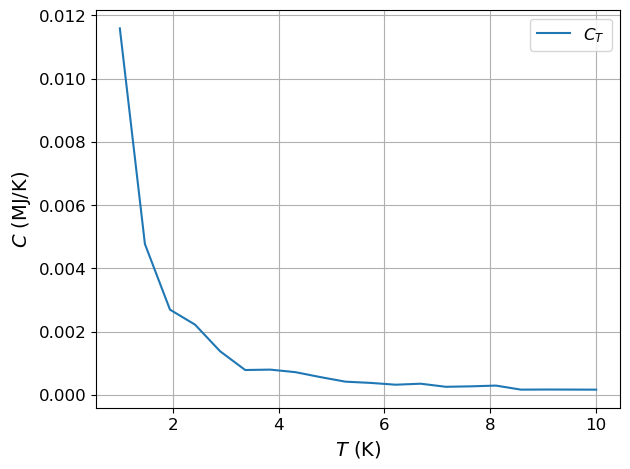

In [27]:
#Computing C(T)
C_T = (E_avg_sqr-E_avg**2)/T**2
#C_T=np.gradient(E_avg, T) #numerical derivative of E_avg with respect to T, divided by T to get C_T. This is because C = dE/dT, and we are using numerical differentiation here.

#Plotting
plt.plot(T,C_T*1e-6, "-", label=rf'$C_T$')
plt.ylabel(r"$C$ (MJ/K)", fontsize=14)
plt.xlabel(r"$T$ (K)", fontsize=14)
plt.xticks(fontsize=12) 
plt.yticks(fontsize=12) 
plt.legend(fontsize=12) 
plt.grid()
plt.tight_layout()
plt.savefig("img/P2/2c.png", dpi=300, bbox_inches='tight')
plt.show()

Discuss the following questions:

- Why does the heat capacity measure energy fluctuations?
- At which temperatures are the fluctuations largest?
- How does the lattice ordering change as the temperature increases?
- Does the peak in $C(T)$ suggest the presence of a phase transition or crossover?

### Part 2d: Surface Grand-Canonical Ensemble

In this exercise, we will explore non-equilibrium effects in a surface-driven grand-canonical simulation.

Use the interactive widget below to run the following KMC simulations:
- Prepare an initial phase-separated structure by running a canonical ensemble with $ J_1 = -10,\; J_2 = 0,\; T=5.0$.
- Pause the simulation after it has sufficiently phase-separated.
- Continue the simulation by switching to a surface grand-canonical and relatively large chemical potentials $\mu_B = -\mu_R \approx 5.$

Experiment with different temperatures and chemical potentials, and observe how the lattice evolves over time.
In particular, look for:

- The formation of interior domains or “islands”
- Competition between different ordered regions
- Slow evolution toward equilibrium
- Metastable states in which the lattice becomes kinetically trapped

Discuss the following questions:

- Why can isolated islands persist for long times?
- Why does the system sometimes become trapped in partially ordered states?
- How does temperature affect the ability of the lattice to escape these metastable configurations?
- What is the difference between thermodynamic equilibrium and kinetic accessibility?

In [ ]:
#| label: interactive-kmc-widget
interactive_kmc_canvas(
    lattice,
    vacancy_coords,
    run_simulation,
    T=5.0,
    J1=0.0, J2=0.0,
    muB=0.0, muR=0.0,
    mode=MODE_CANONICAL,
    steps_per_frame=100,
    interval=100,
) 